# Entrenamiento multitarea PENGWIN — Miguel

Entrena **backbone + CBAM + cabeza de detección (Fabián) + decoder de segmentación (Annie)** reutilizando las definiciones ya escritas por el equipo (sin redefinirlas), con el mismo cargador por AST del cuaderno de Hoyos.

**Qué hace**
1. Carga las definiciones de `proyecto_pengwin.ipynb` (datos, backbone, decoder, targets), de `cbam.ipynb` (CBAM y compuerta residual) e **importa `deteccion_grid.py`** (cabeza grid, targets, pérdida y decodificación de Fabián). `cbam.ipynb` no contiene la cabeza de detección: vive en `deteccion_grid.py` / `cabeza_grid.ipynb`.
2. Materializa los cortes en una **caché** (una sola vez): el dataset de Daniela guarda *un solo caso* en memoria, así que un DataLoader con `shuffle=True` recargaría un volumen MHA casi en cada muestra.
3. Entrena **por etapas**: A) detección, B) decoder con cajas reales perturbadas, C) conjunto con transición gradual a cajas predichas.
4. Valida en `eval()` sobre **todo** el split `val` (nunca `test`), elige el checkpoint con `val` y registra pérdidas por término, normas de gradiente y versiones de datos.

**Marcadores de posición (provisionales)**
- `predicted_boxes_top1`: sustituye al NMS de Fabián (una caja por clase, la de mayor score). Cambiar por su NMS cuando esté listo.
- Épocas, tasas de aprendizaje, `JITTER_PX`, `GRAD_CLIP` y pesos son **puntos de partida**, no valores optimizados.

>  Empezar con `SMOKE_TEST = True` para comprobar que todo conecta antes de una corrida larga.

In [16]:
import gc, hashlib, json, math, random, subprocess, sys, time, ast
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import SimpleITK as sitk
from scipy.ndimage import maximum_filter
from skimage.filters import threshold_otsu            # los usa enhance_bone_contrast (Otsu + CLAHE del preprocesamiento)
from skimage.exposure import equalize_adapthist

# ------------------------------------------------------------------ configuración
ROOT = Path.cwd()
BASE_DIR = ROOT                 # nombre global que usan las definiciones del equipo
SEED = 42
SMOKE_TEST = False              # True: corrida mini (64 cortes, 1 época por etapa)

IMAGE_SIZE = 256
GRID_SIZE = 16
BACKBONE_NAME = "plus"          # "base" | "plus"
USE_CBAM = True
USE_SKIPS = True                # decoder con skip connections del backbone; False = baseline tipo FCN (misma profundidad y anchos), para la ablación
USE_CBAM_GATE = True            # True: compuerta residual y = x + gamma*(CBAM(x)-x), gamma inicia en 0 (diseño del equipo); False: CBAM crudo

BATCH_SIZE = 16
VAL_BATCH_SIZE = 16
NUM_WORKERS = 0                 # >0 solo en Linux/Colab; en Windows dentro de notebooks suele fallar
MAX_TRAIN_SLICES = None         # int para depurar
MAX_VAL_SLICES = None

WEIGHT_DECAY = 1e-4
GRAD_CLIP = 10.0                # norma máxima del gradiente (en la overfit de Hoyos llegó a ~18)
SEG_WEIGHTS = (1.0, 1.0, 1.0)   # semantic, center, offset (iguales, como en la guía de Annie)

DET_LAMBDAS_SOURCE = "loaded"   # "loaded" (los LAMBDAS de deteccion_grid.py) | "fabian_tuned" (copia local de abajo)
LAMBDAS_FABIAN_TUNED = {"obj": 0.46, "box": 2.90, "cls": 2.03, "noobj": 1.0, "l1": 1.0, "iou": 1.0}

JITTER_PX = 8.0                 # desplazamiento máximo de cada coordenada de caja (limitado al 20% del lado)
PRED_BOX_SCORE_MIN = 0.05       # score mínimo para aceptar una caja predicha como prior
INSTANCE_EVAL_N = 128           # cortes de val para la métrica de instancias (decodificación lenta)
EVAL_SCORE_MIN = 0.01           # score mínimo de candidatas en el AP (igual que Hoyos)
LOG_GRAD_EVERY = 50             # cada cuántas iteraciones medir normas de gradiente por módulo

STAGES = [
    {"name": "A_deteccion", "epochs": 10, "lr": 1e-3,
     "train": ["backbone", "cbam", "det_head"],
     "w_det": 1.0, "w_seg": 0.0, "prior": "gt", "select": "det"},
    {"name": "B_decoder", "epochs": 10, "lr": 1e-3,
     "train": ["seg_decoder"],
     "w_det": 0.0, "w_seg": 1.0, "prior": "gt_jitter", "select": "seg_gt"},
    {"name": "C_conjunto", "epochs": 10, "lr": 3e-4,
     "train": ["backbone", "cbam", "det_head", "seg_decoder"],
     "w_det": 1.0, "w_seg": 1.0, "prior": "mixed", "p_pred_end": 0.5, "select": "both"},
]

if SMOKE_TEST:
    MAX_TRAIN_SLICES, MAX_VAL_SLICES, INSTANCE_EVAL_N = 64, 32, 8
    BATCH_SIZE, VAL_BATCH_SIZE = 8, 8
    for _s in STAGES:
        _s["epochs"] = 1

OUT_DIR = ROOT / "evidencias" / ("entrenamiento_multitarea_smoke" if SMOKE_TEST else "entrenamiento_multitarea")
CACHE_DIR = ROOT / "evidencias" / "cache_entrenamiento"     # pesado: añadir a .gitignore
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"


def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False


def autocast():
    return torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP)


seed_everything(SEED)
print(f"PyTorch {torch.__version__} | dispositivo: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")
      + f" | AMP: {USE_AMP} | SMOKE_TEST: {SMOKE_TEST}")
print("Salidas en:", OUT_DIR)

PyTorch 2.11.0+cu128 | dispositivo: cuda (NVIDIA GeForce RTX 5060) | AMP: True | SMOKE_TEST: False
Salidas en: d:\proyecto_analitica_corte2\evidencias\entrenamiento_multitarea


## 1. Cargar las definiciones del equipo
Mismo mecanismo que el cuaderno de Hoyos: extrae por AST solo clases, funciones y constantes (no ejecuta las celdas de prueba). Si falta alguna, se detiene con un error.

In [17]:
def _target_names(node):
    targets = node.targets if isinstance(node, ast.Assign) else [node.target] if isinstance(node, ast.AnnAssign) else []
    names = set()
    for target in targets:
        if isinstance(target, ast.Name):
            names.add(target.id)
        elif isinstance(target, (ast.Tuple, ast.List)):
            names.update(item.id for item in target.elts if isinstance(item, ast.Name))
    return names


def _load_existing_definitions(notebook_path, definition_names, value_names=()):
    notebook_path = Path(notebook_path)
    if not notebook_path.exists():
        raise FileNotFoundError(f"No encuentro el cuaderno del equipo: {notebook_path}")
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    wanted_defs, wanted_values = set(definition_names), set(value_names)
    snippets, found_defs, found_values = [], set(), set()
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        try:
            tree = ast.parse(source)
        except SyntaxError:
            continue
        for node in tree.body:
            name = getattr(node, "name", None)
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and name in wanted_defs and name not in found_defs:
                snippets.append(ast.get_source_segment(source, node)); found_defs.add(name)
            elif isinstance(node, (ast.Assign, ast.AnnAssign)):
                selected = _target_names(node) & wanted_values
                if selected and not selected.issubset(found_values):
                    snippets.append(ast.get_source_segment(source, node)); found_values.update(selected)
    missing_defs, missing_values = wanted_defs - found_defs, wanted_values - found_values
    if missing_defs or missing_values:
        raise RuntimeError(f"Faltan definiciones en {notebook_path.name}: "
                           f"funciones/clases={sorted(missing_defs)}, constantes={sorted(missing_values)}")
    exec("\n\n".join(snippets), globals())
    return len(snippets)


n_proj = _load_existing_definitions(
    ROOT / "proyecto_pengwin.ipynb",
    definition_names={
        # datos y targets (Daniela)
        "resolve_repo_path", "apply_hu_window", "enhance_bone_contrast", "instance_to_semantic", "boxes_from_semantic",
        "letterbox_pair", "build_detection_target", "PengwinDetectionDataset",
        # backbone (Miguel)
        "FundidoraPC", "FundidoraPCPlus", "build_backbone",
        # segmentación (Annie, sección 23)
        "build_instance_segmentation_targets", "build_detection_region_priors",
        "SegmentationConvBlock", "backbone_feature_pyramid", "SkipFusionBlock", "CenterOffsetSkipDecoder",
        "center_offset_segmentation_loss", "decode_center_offset_instances",
    },
    value_names={"CLASS_ID_TO_NAME", "TARGET_COLORS"},
)
# CBAM y compuerta residual (Annie): viven en cbam.ipynb
n_att = _load_existing_definitions(
    ROOT / "cbam.ipynb",
    definition_names={"ChannelAttention", "SpatialAttention", "CBAM", "CompuertaResidualCBAM"},
)

# Cabeza de detección grid, targets y pérdida (Fabián): NO están en cbam.ipynb, están en deteccion_grid.py
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
try:
    from deteccion_grid import (
        box_iou, pairwise_iou, encode_boxes, decode_boxes, build_targets, GridDetectionHead,
        split_head_output, grid_detection_loss, decode_predictions,
        GRID_S, IMG_SIZE, STRIDE, CH_OBJ, CH_BOX, CH_CLS, LAMBDAS, CLASS_NAMES,
    )
except ModuleNotFoundError as exc:
    raise FileNotFoundError(f"No encuentro deteccion_grid.py en {ROOT}: ponerlo junto a este cuaderno") from exc
print(f"proyecto_pengwin.ipynb: {n_proj} definiciones | cbam.ipynb: {n_att} definiciones | deteccion_grid.py: importado")
assert GRID_S == GRID_SIZE and IMG_SIZE == IMAGE_SIZE, "la cabeza grid espera otra resolución"

# --- pesos de la pérdida de detección: conviene confirmar cuáles son los oficiales ---
DET_LAMBDAS = dict(LAMBDAS) if DET_LAMBDAS_SOURCE == "loaded" else dict(LAMBDAS_FABIAN_TUNED)
print("LAMBDAS cargados de deteccion_grid.py:", LAMBDAS)
print("LAMBDAS afinados por Fabián    :", LAMBDAS_FABIAN_TUNED)
print(f"Se usan ({DET_LAMBDAS_SOURCE}):", DET_LAMBDAS)
if dict(LAMBDAS) != LAMBDAS_FABIAN_TUNED:
    print("AVISO: no coinciden. Acordar con Fabián cuáles son los oficiales y fijar DET_LAMBDAS_SOURCE.")

# --- tablas que usa PengwinDetectionDataset (variables globales df y slice_manifest) ---
dataset_csv = ROOT / "splits" / "dataset.csv"
manifest_csv = ROOT / "evidencias" / "datos_targets" / "manifest_cortes_positivos.csv"
for _p in (dataset_csv, manifest_csv):
    if not _p.exists():
        raise FileNotFoundError(f"Falta {_p}")
df = pd.read_csv(dataset_csv, dtype={"case_id": str})
slice_manifest = pd.read_csv(manifest_csv, dtype={"case_id": str})
print("Cortes por split en el manifiesto:", slice_manifest["split"].value_counts().to_dict())
print("NOTA: el manifiesto solo tiene cortes POSITIVOS (con hueso); el modelo no verá cortes vacíos.")

proyecto_pengwin.ipynb: 21 definiciones | cbam.ipynb: 4 definiciones | deteccion_grid.py: importado
LAMBDAS cargados de deteccion_grid.py: {'obj': 0.46, 'box': 2.9, 'cls': 2.03, 'noobj': 1.0, 'l1': 1.0, 'iou': 1.0}
LAMBDAS afinados por Fabián    : {'obj': 0.46, 'box': 2.9, 'cls': 2.03, 'noobj': 1.0, 'l1': 1.0, 'iou': 1.0}
Se usan (loaded): {'obj': 0.46, 'box': 2.9, 'cls': 2.03, 'noobj': 1.0, 'l1': 1.0, 'iou': 1.0}
Cortes por split en el manifiesto: {'train': 18072, 'test': 4897, 'val': 1265}
NOTA: el manifiesto solo tiene cortes POSITIVOS (con hueso); el modelo no verá cortes vacíos.


## 2. Caché de cortes (una sola vez)
`PengwinDetectionDataset` guarda **un solo caso** en memoria. Con `shuffle=True`, casi cada muestra obligaría a releer un MHA completo. Aquí se recorre el dataset **en orden de caso** una vez y se guardan imágenes (`float16`), máscaras de instancia (`uint8`, IDs ≤ 30) y cajas. La caché se invalida sola si cambian `dataset.csv`, el manifiesto o los parámetros.

**Memoria.** Construir la caché es la parte que más RAM pide. Para no agotarla:
- `LeanPengwinDetectionDataset` (subclase de la de Daniela, mismo resultado numérico) lee cada volumen **sin copiarlo** (`GetArrayViewFromImage`), lo conserva en su tipo original (p. ej. `int16`) y convierte a `float32` **solo el corte** que se usa; además **libera el caso anterior antes de leer el siguiente**. La versión original convertía el volumen completo a `float32` y mantenía dos volúmenes a la vez durante el cambio de caso.
- `images.npy` e `inst.npy` se escriben directamente en disco (`open_memmap`) en vez de reservar los arreglos completos en RAM mientras hay un volumen abierto.
- `key.json` se escribe al final: una construcción interrumpida no se toma por válida y se rehace sola.

In [18]:
def _sha1(path, n=12):
    h = hashlib.sha1()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()[:n]


DATA_VERSION = {"dataset_csv": _sha1(dataset_csv), "manifest": _sha1(manifest_csv),
                "image_size": IMAGE_SIZE, "channels": 1}


class _VolumeSlices:
    """Volumen en su tipo original; entrega cada corte convertido a `dtype` (mismos valores que convertir el volumen completo)."""
    def __init__(self, array, owner, dtype):
        self.array, self._owner, self.dtype = array, owner, dtype     # owner mantiene vivo el objeto SimpleITK de la vista
    def __getitem__(self, index):
        return self.array[index].astype(self.dtype)


class LeanPengwinDetectionDataset(PengwinDetectionDataset):
    """Igual que PengwinDetectionDataset, pero sin copiar ni convertir a float32 el volumen completo
    y liberando el caso anterior antes de leer el siguiente (evita 'Failed to allocate memory for image')."""
    def _load_case(self, case_id):
        if case_id != self._cached_case_id:
            self._image = self._label = None            # suelta el caso anterior ANTES de leer el nuevo
            self._cached_case_id = None
            gc.collect()
            row = df[df["case_id"] == case_id].iloc[0]
            image_itk = sitk.ReadImage(str(resolve_repo_path(row["image_path"])))
            label_itk = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
            self._image = _VolumeSlices(sitk.GetArrayViewFromImage(image_itk), image_itk, np.float32)
            self._label = _VolumeSlices(sitk.GetArrayViewFromImage(label_itk), label_itk, np.int16)
            self._spacing = tuple(float(value) for value in image_itk.GetSpacing())
            self._cached_case_id = case_id
        return self._image, self._label, self._spacing


def build_or_load_cache(split, max_slices=None):
    tag = split if max_slices is None else f"{split}_first{max_slices}"
    folder = CACHE_DIR / tag
    key = {**DATA_VERSION, "max_slices": max_slices}
    key_path = folder / "key.json"
    if key_path.exists() and json.loads(key_path.read_text()) == key:
        return _read_cache(split, folder)

    folder.mkdir(parents=True, exist_ok=True)
    ds = LeanPengwinDetectionDataset(split=split, image_size=IMAGE_SIZE, channels=1, as_torch=False)
    order = sorted(range(len(ds)), key=lambda i: (ds.records[i]["case_id"], int(ds.records[i]["slice_index"])))
    if max_slices:
        order = order[:max_slices]
    n, S = len(order), IMAGE_SIZE
    # se escribe directo a disco: no se reservan ~GB en RAM mientras hay un volumen abierto
    images = np.lib.format.open_memmap(folder / "images.npy", mode="w+", dtype=np.float16, shape=(n, 1, S, S))
    inst = np.lib.format.open_memmap(folder / "inst.npy", mode="w+", dtype=np.uint8, shape=(n, S, S))
    boxes_list, labels_list, case_ids, slice_ids = [], [], [], []
    t0 = time.perf_counter()
    for k, i in enumerate(order):
        image, target = ds[i]
        image = np.asarray(image, dtype=np.float32)
        mask = np.asarray(target["instance_mask"])
        assert image.shape == (1, S, S), image.shape
        assert mask.shape == (S, S) and 0 <= mask.min() and mask.max() <= 30, (mask.shape, mask.min(), mask.max())
        images[k] = image.astype(np.float16)
        inst[k] = mask.astype(np.uint8)
        boxes_list.append(np.asarray(target["boxes"], dtype=np.float32).reshape(-1, 4))
        labels_list.append(np.asarray(target["labels"]).astype(np.int64).reshape(-1))
        case_ids.append(str(target["case_id"])); slice_ids.append(int(target["slice_index"]))
        if (k + 1) % 1000 == 0 or k + 1 == n:
            print(f"[{split}] {k + 1}/{n} cortes | {time.perf_counter() - t0:.0f} s")

    boxes, labels = pad_boxes(boxes_list, labels_list)
    meta = pd.DataFrame({"case_id": case_ids, "slice_index": slice_ids})
    images.flush(); inst.flush()
    del images, inst, ds                                  # cierra los archivos y suelta el último volumen
    gc.collect()
    np.save(folder / "boxes.npy", boxes); np.save(folder / "labels.npy", labels)
    meta.to_csv(folder / "meta.csv", index=False)
    key_path.write_text(json.dumps(key))                  # al final: una construcción interrumpida no queda como válida
    print(f"[{split}] caché creada: {n} cortes, {len(set(case_ids))} casos ({folder})")
    return _read_cache(split, folder, quiet=True)


def _read_cache(split, folder, quiet=False):
    cache = {
        "images": np.load(folder / "images.npy"), "inst": np.load(folder / "inst.npy"),
        "boxes": np.load(folder / "boxes.npy"), "labels": np.load(folder / "labels.npy"),
        "meta": pd.read_csv(folder / "meta.csv", dtype={"case_id": str}),
    }
    if not quiet:
        print(f"[{split}] caché cargada: {len(cache['images'])} cortes ({folder})")
    return cache


def pad_boxes(boxes_list, labels_list):
    # cajas de longitud variable -> arreglos con relleno (label 0 = relleno)
    k = max(1, max(len(b) for b in boxes_list))
    n = len(boxes_list)
    boxes = np.zeros((n, k, 4), dtype=np.float32)
    labels = np.zeros((n, k), dtype=np.int64)
    for i, (b, l) in enumerate(zip(boxes_list, labels_list)):
        boxes[i, :len(b)] = b
        labels[i, :len(l)] = l
    return boxes, labels


def unpad_boxes(boxes_pad, labels_pad):
    valid = labels_pad > 0
    return boxes_pad[valid].copy(), labels_pad[valid].copy()


train_cache = build_or_load_cache("train", MAX_TRAIN_SLICES)
val_cache = build_or_load_cache("val", MAX_VAL_SLICES)
print("Casos en train:", train_cache["meta"]["case_id"].nunique(), "| casos en val:", val_cache["meta"]["case_id"].nunique())
assert not (set(train_cache["meta"]["case_id"]) & set(val_cache["meta"]["case_id"])), "casos repartidos entre train y val"

[train] caché cargada: 18072 cortes (d:\proyecto_analitica_corte2\evidencias\cache_entrenamiento\train)
[val] caché cargada: 1265 cortes (d:\proyecto_analitica_corte2\evidencias\cache_entrenamiento\val)
Casos en train: 75 | casos en val: 5


In [19]:
class CachedSliceDataset(torch.utils.data.Dataset):
    # Cortes en memoria. Los targets de segmentación (centros/offsets) se generan al vuelo
    # con la función de Annie: guardarlos ocuparía ~10 GB.
    def __init__(self, cache):
        self.images, self.inst = cache["images"], cache["inst"]
        self.boxes, self.labels, self.meta = cache["boxes"], cache["labels"], cache["meta"]
        self.case_ids = self.meta["case_id"].tolist()
        self.slice_ids = self.meta["slice_index"].tolist()
        self.need_seg = True        # False: no se generan centros/offsets/semántica (la etapa A solo entrena detección)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        inst = self.inst[i].astype(np.int32)
        boxes, labels = unpad_boxes(self.boxes[i], self.labels[i])
        item = {
            "image": torch.from_numpy(self.images[i].astype(np.float32)),
            "instance_mask": torch.from_numpy(inst),
            "boxes": boxes, "labels": labels,
            "case_id": self.case_ids[i], "slice_index": self.slice_ids[i],
        }
        if self.need_seg:
            seg = build_instance_segmentation_targets(inst)
            item.update({"semantic": torch.from_numpy(seg["semantic"]),
                         "centers": torch.from_numpy(seg["centers"]),
                         "offsets": torch.from_numpy(seg["offsets"]),
                         "foreground": torch.from_numpy(seg["foreground"])})
        return item


def collate_slices(batch):
    keys = ("image", "instance_mask") + (("semantic", "centers", "offsets", "foreground") if "semantic" in batch[0] else ())
    out = {k: torch.stack([b[k] for b in batch]) for k in keys}
    out["boxes"] = [b["boxes"] for b in batch]
    out["labels"] = [b["labels"] for b in batch]
    out["case_id"] = [b["case_id"] for b in batch]
    out["slice_index"] = [b["slice_index"] for b in batch]
    return out


_gen = torch.Generator(); _gen.manual_seed(SEED)
train_loader = torch.utils.data.DataLoader(
    CachedSliceDataset(train_cache), batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda", collate_fn=collate_slices, generator=_gen)
val_loader = torch.utils.data.DataLoader(
    CachedSliceDataset(val_cache), batch_size=VAL_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda", collate_fn=collate_slices)

_t = time.perf_counter(); _b = next(iter(train_loader)); _dt = time.perf_counter() - _t
print(f"train: {len(train_loader.dataset)} cortes, {len(train_loader)} iteraciones/época | val: {len(val_loader.dataset)} cortes")
print(f"Un batch: imagen {tuple(_b['image'].shape)}, semántica {tuple(_b['semantic'].shape)}, "
      f"centros {tuple(_b['centers'].shape)}, offsets {tuple(_b['offsets'].shape)} | tiempo de carga: {_dt * 1000:.0f} ms")

train: 18072 cortes, 1129 iteraciones/época | val: 1265 cortes
Un batch: imagen (16, 1, 256, 256), semántica (16, 256, 256), centros (16, 3, 256, 256), offsets (16, 2, 256, 256) | tiempo de carga: 46 ms


## 3. Modelo multitarea
Tronco compartido (backbone → CBAM) y dos ramas: cabeza de detección y decoder de segmentación **con skip connections** (`CenterOffsetSkipDecoder`: usa los mapas del backbone a stride 8, 4 y 2 y la imagen a resolución completa; con `USE_SKIPS = False` queda como baseline FCN con la misma profundidad). Se arma con las piezas del equipo. Con `base` + CBAM crudo la suma de parámetros de backbone + CBAM + cabeza debe dar **693,290** (388,800 + 8,290 + 296,200); la compuerta residual agrega **1** parámetro (γ), así que con `USE_CBAM_GATE = True` da **693,291**. A eso se suman los del decoder.

In [20]:
class MultiTaskNet(nn.Module):
    def __init__(self, backbone_name="base", use_cbam=True, use_gate=True, use_skips=True):
        super().__init__()
        self.backbone = build_backbone(backbone_name, in_channels=1)
        if not use_cbam:
            self.cbam = None
        else:
            # Compuerta residual (gamma inicia en 0): al empezar, el tronco es idéntico al backbone sin atención
            self.cbam = CompuertaResidualCBAM(CBAM(256)) if use_gate else CBAM(256)
        self.det_head = GridDetectionHead()
        self.seg_decoder = CenterOffsetSkipDecoder(in_channels=256, image_channels=1, use_skips=use_skips)

    def trunk(self, x):
        # Pirámide [f1 (32,128²), f2 (64,64²), f3 (128,32²), f4 (256,16²)]; f4 == backbone._encode(x) (incluye el contexto de 'plus').
        feats = backbone_feature_pyramid(self.backbone, x)
        if self.cbam is not None:
            feats[-1], _, _ = self.cbam(feats[-1])  # CBAM devuelve (y, atención de canal, atención espacial); solo se refina f4
        return feats

    def forward(self, x, region_priors=None):
        feats = self.trunk(x)
        det_logits = self.det_head(feats[-1])
        seg_out = self.seg_decoder(x, feats, region_priors) if region_priors is not None else None
        return det_logits, seg_out


def count_params(module):
    return sum(p.numel() for p in module.parameters())


seed_everything(SEED)
model = MultiTaskNet(BACKBONE_NAME, USE_CBAM, USE_CBAM_GATE, USE_SKIPS).to(DEVICE)
for name, child in model.named_children():
    print(f"{name:12s} {count_params(child):>10,} parámetros")
print(f"{'TOTAL':12s} {count_params(model):>10,}")
_det_total = sum(count_params(getattr(model, n)) for n in ("backbone", "cbam", "det_head") if getattr(model, n) is not None)
_esperado = 693_290 + (1 if USE_CBAM_GATE else 0)
print("backbone + CBAM + cabeza:", f"{_det_total:,}", f"(esperado {_esperado:,} con base + CBAM)" if BACKBONE_NAME == "base" and USE_CBAM else "")
if BACKBONE_NAME == "base" and USE_CBAM:
    assert _det_total == _esperado, "el conteo de parámetros no coincide con las piezas del equipo (backbone + CBAM + deteccion_grid)"

# El tronco con pirámide debe producir EXACTAMENTE el mapa f4 que usaba la cabeza de detección (backbone -> CBAM).
with torch.no_grad():
    _probe = torch.rand(2, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    model.eval()
    _, _fmap_old = model.backbone(_probe)
    if model.cbam is not None:
        _fmap_old, _, _ = model.cbam(_fmap_old)
    assert torch.allclose(model.trunk(_probe)[-1], _fmap_old, atol=1e-5), "el tronco ya no coincide con backbone -> CBAM"
    model.train()
print("Tronco con pirámide == backbone -> CBAM (contrato de la cabeza de detección): OK")

backbone      1,569,472 parámetros
cbam              8,291 parámetros
det_head        296,200 parámetros
seg_decoder     633,716 parámetros
TOTAL         2,507,679
backbone + CBAM + cabeza: 1,873,963 
Tronco con pirámide == backbone -> CBAM (contrato de la cabeza de detección): OK


## 4. Cajas guía (priors), objetivos y pérdidas
- `gt`: cajas reales. `gt_jitter`: cajas reales con jitter (reduce el atajo de "copiar la caja"). `pred`: cajas predichas. `mixed`: por muestra, con probabilidad `p_pred` cajas predichas y si no, reales con jitter.
- `predicted_boxes_top1` es un **marcador de posición del NMS**: cada corte tiene como máximo una caja por clase.

In [21]:
def jitter_boxes(boxes, rng, jitter_px=JITTER_PX):
    # Desplaza cada coordenada hasta jitter_px, sin superar el 20% del lado menor (la caja sigue siendo válida).
    boxes = np.asarray(boxes, dtype=np.float32).reshape(-1, 4)
    if len(boxes) == 0:
        return boxes
    w, h = boxes[:, 2] - boxes[:, 0], boxes[:, 3] - boxes[:, 1]
    j = np.minimum(jitter_px, 0.2 * np.minimum(w, h))[:, None]
    out = boxes + rng.uniform(-1.0, 1.0, size=boxes.shape).astype(np.float32) * j
    return np.clip(out, 0, IMAGE_SIZE).astype(np.float32)


def predicted_boxes_top1(decoded_i, score_min=PRED_BOX_SCORE_MIN):
    # MARCADOR DE POSICIÓN del NMS de Fabián: una caja por clase (la de mayor score).
    boxes, labels = [], []
    for c in (1, 2, 3):
        idx = (decoded_i["labels"] == c).nonzero(as_tuple=True)[0]
        if len(idx) == 0:
            continue
        j = idx[decoded_i["scores"][idx].argmax()]
        if float(decoded_i["scores"][j]) >= score_min:
            boxes.append(decoded_i["boxes"][j].detach().cpu().numpy()); labels.append(c)
    return np.asarray(boxes, dtype=np.float32).reshape(-1, 4), np.asarray(labels, dtype=np.int64)


def make_priors(batch, det_logits, mode, p_pred, rng):
    # mode: "gt" | "gt_jitter" | "pred" | "mixed"
    B = len(batch["boxes"])
    decoded, detections = None, []
    for b in range(B):
        use_pred = mode == "pred" or (mode == "mixed" and rng.random() < p_pred)
        if use_pred:
            if decoded is None:
                decoded = decode_predictions(det_logits.detach().float(), score_thresh=0.0, img_size=IMAGE_SIZE)
            boxes, labels = predicted_boxes_top1(decoded[b])
        elif mode in ("gt_jitter", "mixed"):
            boxes, labels = jitter_boxes(batch["boxes"][b], rng), batch["labels"][b]
        else:
            boxes, labels = batch["boxes"][b], batch["labels"][b]
        detections.append({"boxes": boxes, "labels": labels})
    return build_detection_region_priors(detections, output_size=(IMAGE_SIZE, IMAGE_SIZE), device=DEVICE)


def make_grid_targets(batch):
    tg = [{"boxes": torch.as_tensor(b, dtype=torch.float32), "labels": torch.as_tensor(l, dtype=torch.long)}
          for b, l in zip(batch["boxes"], batch["labels"])]
    return build_targets(tg, grid_s=GRID_SIZE, img_size=IMAGE_SIZE)


def seg_loss_from_batch(seg_out, batch):
    return center_offset_segmentation_loss(
        seg_out, batch["semantic"].to(DEVICE), batch["centers"].to(DEVICE),
        batch["offsets"].to(DEVICE), batch["foreground"].to(DEVICE), weights=SEG_WEIGHTS)


def compute_losses(det_logits, seg_out, batch, grid_t, w_det, w_seg):
    out, total = {}, 0.0
    if w_det > 0:
        det = grid_detection_loss(det_logits.float(), grid_t, lambdas=DET_LAMBDAS)
        out.update({f"det_{k}": v for k, v in det.items()})
        total = total + w_det * det["total"]
    if w_seg > 0:
        seg = seg_loss_from_batch(seg_out, batch)
        out.update({f"seg_{k}": v for k, v in seg.items()})
        total = total + w_seg * seg["total"]
    out["total"] = total
    return out

## 5. Métricas de validación
Detección: mismas definiciones que el cuaderno de Hoyos (IoU del candidato de mayor score por clase, recall@0.5/0.75, AP@0.5), **con una corrección**: el AP se calcula sobre las clases `1, 2, 3`. En su versión el bucle era `range(3)` = `0, 1, 2`, que deja fuera `coxal_derecho` (clase 3) e incluye una clase 0 inexistente. Conviene confirmarlo con él.

Segmentación: Dice/IoU semántico por región (vectorizado) y recall de fragmentos (IoU ≥ 0.5) sobre un subconjunto de `val`. Cada métrica de segmentación se mide con **cajas reales** (`gt`) y con **cajas predichas** (`pred`) para ver la brecha que preocupa a Annie.

In [22]:
def _to_np(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


def _iou_np(box, boxes):
    boxes = np.asarray(boxes, dtype=np.float64).reshape(-1, 4)
    x1 = np.maximum(box[0], boxes[:, 0]); y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2]); y2 = np.minimum(box[3], boxes[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area_a = max(box[2] - box[0], 0) * max(box[3] - box[1], 0)
    area_b = np.clip(boxes[:, 2] - boxes[:, 0], 0, None) * np.clip(boxes[:, 3] - boxes[:, 1], 0, None)
    return inter / np.maximum(area_a + area_b - inter, 1e-9)


def _average_precision(decoded, targets, class_id, iou_thr=0.5):
    detections, gts, n_gt = [], {}, 0
    for i, (pred, tgt) in enumerate(zip(decoded, targets)):
        g_boxes = _to_np(tgt["boxes"]).reshape(-1, 4)
        g_labels = _to_np(tgt["labels"]).astype(int).reshape(-1)
        g_boxes = g_boxes[g_labels == class_id]
        gts[i] = (g_boxes, np.zeros(len(g_boxes), dtype=bool))
        n_gt += len(g_boxes)
        p_boxes = _to_np(pred["boxes"]).reshape(-1, 4)
        p_scores = _to_np(pred["scores"]).reshape(-1)
        p_labels = _to_np(pred["labels"]).astype(int).reshape(-1)
        keep = (p_labels == class_id) & (p_scores >= EVAL_SCORE_MIN)
        detections.extend((float(s), i, b) for s, b in zip(p_scores[keep], p_boxes[keep]))
    if n_gt == 0:
        return None
    detections.sort(key=lambda d: -d[0])
    tp, fp = np.zeros(len(detections)), np.zeros(len(detections))
    for k, (_, i, box) in enumerate(detections):
        g_boxes, used = gts[i]
        if len(g_boxes) == 0:
            fp[k] = 1; continue
        ious = _iou_np(box, g_boxes)
        j = int(ious.argmax())
        if ious[j] >= iou_thr and not used[j]:
            used[j] = True; tp[k] = 1
        else:
            fp[k] = 1
    tp, fp = np.cumsum(tp), np.cumsum(fp)
    recall, precision = tp / n_gt, tp / np.maximum(tp + fp, 1e-9)
    mrec = np.concatenate([[0.0], recall, [1.0]]); mpre = np.concatenate([[0.0], precision, [0.0]])
    for k in range(len(mpre) - 2, -1, -1):
        mpre[k] = max(mpre[k], mpre[k + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def detection_metrics(decoded, targets, class_ids=(1, 2, 3)):
    ious = []
    for pred, tgt in zip(decoded, targets):
        p_boxes = _to_np(pred["boxes"]).reshape(-1, 4)
        p_scores = _to_np(pred["scores"]).reshape(-1)
        p_labels = _to_np(pred["labels"]).astype(int).reshape(-1)
        for g_box, g_label in zip(_to_np(tgt["boxes"]).reshape(-1, 4), _to_np(tgt["labels"]).astype(int).reshape(-1)):
            same = np.flatnonzero(p_labels == g_label)
            if len(same) == 0:
                ious.append(0.0); continue
            best = same[p_scores[same].argmax()]
            ious.append(float(_iou_np(g_box, p_boxes[best:best + 1])[0]))
    ious = np.asarray(ious) if ious else np.zeros(1)
    aps = {c: _average_precision(decoded, targets, c) for c in class_ids}
    valid = [a for a in aps.values() if a is not None]
    return {"mean_iou": float(ious.mean()), "recall50": float((ious >= 0.5).mean()),
            "recall75": float((ious >= 0.75).mean()),
            "map50": float(np.mean(valid)) if valid else float("nan"), "ap_by_class": aps}


def fragment_hits(pred_inst, gt_inst, thr=0.5):
    # Fragmentos GT (ids != 0) cuyo mejor IoU con algún fragmento predicho es >= thr.
    gt_ids = [int(i) for i in np.unique(gt_inst) if i != 0]
    pred_masks = [pred_inst == int(p) for p in np.unique(pred_inst) if p != 0]
    hits = 0
    for g in gt_ids:
        gm = gt_inst == g
        best = 0.0
        for pm in pred_masks:
            inter = np.logical_and(gm, pm).sum()
            if inter:
                best = max(best, inter / np.logical_or(gm, pm).sum())
        hits += int(best >= thr)
    return hits, len(gt_ids)

In [23]:
@torch.no_grad()
def evaluate(model, loader, run_seg, instance_n=INSTANCE_EVAL_N):
    model.eval()
    rng = np.random.default_rng(SEED)
    decoded_all, targets_all = [], []
    det_sum, n_img = defaultdict(float), 0
    modes = ("gt", "pred")
    acc = {m: {c: {"inter": 0.0, "psum": 0.0, "gsum": 0.0} for c in (1, 2, 3)} for m in modes}
    inst = {m: {"hit": 0, "total": 0} for m in modes}
    seg_loss_sum, inst_seen = 0.0, 0

    for batch in loader:
        B = len(batch["boxes"])
        x = batch["image"].to(DEVICE, non_blocking=True)
        grid_t = make_grid_targets(batch)
        with autocast():
            feats = model.trunk(x)
            det_logits = model.det_head(feats[-1])
        det = grid_detection_loss(det_logits.float(), grid_t, lambdas=DET_LAMBDAS)
        for k in ("total", "obj", "box", "cls"):
            det_sum[k] += float(det[k]) * B
        n_img += B
        decoded_all += decode_predictions(det_logits.float(), score_thresh=0.0, img_size=IMAGE_SIZE)
        targets_all += [{"boxes": b, "labels": l} for b, l in zip(batch["boxes"], batch["labels"])]
        if not run_seg:
            continue

        gt_sem = batch["semantic"].to(DEVICE)
        take = max(0, min(B, instance_n - inst_seen))
        for mode in modes:
            priors = make_priors(batch, det_logits, mode, 0.0, rng)
            with autocast():
                seg_out = model.seg_decoder(x, feats, priors)
            pred = seg_out["semantic_logits"].float().argmax(1)
            for c in (1, 2, 3):
                p, g = pred == c, gt_sem == c
                acc[mode][c]["inter"] += float((p & g).sum()); acc[mode][c]["psum"] += float(p.sum())
                acc[mode][c]["gsum"] += float(g.sum())
            if mode == "gt":
                seg_loss_sum += float(seg_loss_from_batch(seg_out, batch)["total"]) * B
            for i in range(take):
                one = {k: v[i:i + 1].float() for k, v in seg_out.items()}
                pred_inst, _, _ = decode_center_offset_instances(one)
                h, t = fragment_hits(pred_inst, batch["instance_mask"][i].numpy())
                inst[mode]["hit"] += h; inst[mode]["total"] += t
        inst_seen += take

    det_m = detection_metrics(decoded_all, targets_all)
    out = {"val_det_loss": det_sum["total"] / n_img, "val_det_obj": det_sum["obj"] / n_img,
           "val_det_box": det_sum["box"] / n_img, "val_det_cls": det_sum["cls"] / n_img,
           "val_det_mean_iou": det_m["mean_iou"], "val_det_recall50": det_m["recall50"],
           "val_det_recall75": det_m["recall75"], "val_det_map50": det_m["map50"]}
    for c, ap in det_m["ap_by_class"].items():
        out[f"val_det_ap50_c{c}"] = float("nan") if ap is None else ap
    if run_seg:
        out["val_seg_loss_gt"] = seg_loss_sum / n_img
        for mode in modes:
            dices = []
            for c in (1, 2, 3):
                a = acc[mode][c]
                d = 2 * a["inter"] / (a["psum"] + a["gsum"]) if (a["psum"] + a["gsum"]) > 0 else float("nan")
                out[f"val_seg_dice_{mode}_c{c}"] = d
                out[f"val_seg_iou_{mode}_c{c}"] = (a["inter"] / (a["psum"] + a["gsum"] - a["inter"])
                                                  if (a["psum"] + a["gsum"] - a["inter"]) > 0 else float("nan"))
                dices.append(d)
            out[f"val_seg_dice_{mode}"] = float(np.nanmean(dices))
            out[f"val_inst_recall50_{mode}"] = inst[mode]["hit"] / max(inst[mode]["total"], 1)
        out["val_inst_n_gt"] = inst["gt"]["total"]
    return out


def selection_score(kind, v):
    if kind == "det":
        s = v["val_det_map50"]
    elif kind == "seg_gt":
        s = v["val_seg_dice_gt"]
    else:   # "both"
        s = 0.5 * v["val_det_map50"] + 0.5 * v["val_seg_dice_pred"]
    return -math.inf if (s is None or math.isnan(s)) else float(s)

## 6. Bucle de entrenamiento por etapas
- AdamW + `OneCycleLR` por etapa, AMP, recorte de gradiente tras `unscale_`.
- Los módulos que no se entrenan en una etapa se congelan **y** se ponen en `eval()` (para que su BatchNorm no cambie).
- Cada etapa parte del **mejor** checkpoint (por `val`) de la anterior, no del último.
- Se registran por época: pérdidas por término, normas de gradiente por módulo y, en la etapa C, la norma del gradiente que cada rama deja en el primer conv del backbone (para ver cuál domina el tronco compartido).

In [24]:
def set_trainable(model, names):
    for n, child in model.named_children():
        for p in child.parameters():
            p.requires_grad = n in names


def set_train_mode(model, names):
    model.train()
    for n, child in model.named_children():
        if n not in names:
            child.eval()


def group_grad_norms(model, names):
    out = {}
    for n in names:
        child = getattr(model, n)
        if child is None:                       # p. ej. cbam=None en la ablación sin CBAM
            continue
        sq = sum(float(p.grad.detach().float().norm()) ** 2 for p in child.parameters() if p.grad is not None)
        out[f"grad_{n}"] = sq ** 0.5
    return out


def trunk_grad_balance(model, batch, rng):
    # Norma del gradiente de cada rama sobre backbone.conv1 (fp32, eval): ¿quién domina el tronco?
    model.eval()
    x = batch["image"].to(DEVICE)
    grid_t = make_grid_targets(batch)
    feats = model.trunk(x)
    det_logits = model.det_head(feats[-1])
    priors = make_priors(batch, det_logits, "gt_jitter", 0.0, rng)
    seg_out = model.seg_decoder(x, feats, priors)
    det = grid_detection_loss(det_logits.float(), grid_t, lambdas=DET_LAMBDAS)["total"]
    seg = seg_loss_from_batch(seg_out, batch)["total"]
    w = model.backbone.conv1.weight
    g_det = torch.autograd.grad(det, w, retain_graph=True)[0].norm().item()
    g_seg = torch.autograd.grad(seg, w)[0].norm().item()
    return g_det, g_seg


def current_config():
    cfg = {k: globals()[k] for k in (
        "SEED", "IMAGE_SIZE", "GRID_SIZE", "BACKBONE_NAME", "USE_CBAM", "USE_CBAM_GATE", "USE_SKIPS", "BATCH_SIZE", "VAL_BATCH_SIZE",
        "WEIGHT_DECAY", "GRAD_CLIP", "SEG_WEIGHTS", "DET_LAMBDAS_SOURCE", "JITTER_PX", "PRED_BOX_SCORE_MIN",
        "INSTANCE_EVAL_N", "EVAL_SCORE_MIN", "USE_AMP", "SMOKE_TEST", "MAX_TRAIN_SLICES", "MAX_VAL_SLICES")}
    cfg["SEG_WEIGHTS"] = list(SEG_WEIGHTS)
    cfg["DET_LAMBDAS"] = dict(DET_LAMBDAS)
    cfg["STAGES"] = STAGES
    cfg["DATA_VERSION"] = DATA_VERSION
    cfg["torch"] = torch.__version__
    cfg["device"] = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu"
    try:
        cfg["git_commit"] = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True,
                                           cwd=ROOT, timeout=10).stdout.strip() or None
    except Exception:
        cfg["git_commit"] = None
    return cfg


def save_checkpoint(path, model, optimizer, scaler, scheduler, stage, epoch, metrics, config):
    torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                "scaler_state_dict": scaler.state_dict(), "scheduler_state_dict": scheduler.state_dict(),
                "stage": stage["name"], "epoch": epoch,
                "val_metrics": {k: float(v) for k, v in metrics.items()}, "config": config}, path)


def load_weights(model, path):
    state = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(state["model_state_dict"])
    return state


def train_stage(model, stage, train_loader, val_loader, config):
    names = set(stage["train"])
    set_trainable(model, names)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=stage["lr"], weight_decay=WEIGHT_DECAY)
    steps_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=stage["lr"], total_steps=stage["epochs"] * steps_per_epoch, pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    rng = np.random.default_rng(SEED + sum(map(ord, stage["name"])))
    w_det, w_seg = stage["w_det"], stage["w_seg"]
    for _loader in (train_loader, val_loader):          # etapa A: no se calculan centros/offsets (no se usan)
        _loader.dataset.need_seg = w_seg > 0
    need_det = w_det > 0 or stage["prior"] in ("mixed", "pred")
    run_seg_val = w_seg > 0
    best_score, best_path = -math.inf, OUT_DIR / f"best_{stage['name']}.pth"
    diag_batch = next(iter(val_loader)) if (w_det > 0 and w_seg > 0) else None
    rows = []
    print(f"\n=== Etapa {stage['name']} | entrena {sorted(names)} | w_det={w_det} w_seg={w_seg} | "
          f"priors={stage['prior']} | {stage['epochs']} épocas x {steps_per_epoch} iteraciones ===")

    for ep in range(1, stage["epochs"] + 1):
        set_train_mode(model, names)
        p_pred = stage.get("p_pred_end", 0.0) * (ep - 1) / max(stage["epochs"] - 1, 1)
        sums, n_it = defaultdict(float), 0
        gsums, n_g = defaultdict(float), 0
        t_epoch = time.perf_counter(); t_data = 0.0; t_prev = time.perf_counter()
        for it, batch in enumerate(train_loader):
            t_data += time.perf_counter() - t_prev
            x = batch["image"].to(DEVICE, non_blocking=True)
            grid_t = make_grid_targets(batch) if w_det > 0 else None
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                feats = model.trunk(x)
                det_logits = model.det_head(feats[-1]) if need_det else None
                seg_out = None
                if w_seg > 0:
                    priors = make_priors(batch, det_logits, stage["prior"], p_pred, rng)
                    seg_out = model.seg_decoder(x, feats, priors)
            losses = compute_losses(det_logits, seg_out, batch, grid_t, w_det, w_seg)
            if not torch.isfinite(losses["total"]):
                raise RuntimeError(f"Pérdida no finita en etapa {stage['name']}, época {ep}, iteración {it}")
            scaler.scale(losses["total"]).backward()
            scaler.unscale_(optimizer)
            gnorm = torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
            if it % LOG_GRAD_EVERY == 0:
                for k, v in group_grad_norms(model, names).items():
                    gsums[k] += v
                gsums["grad_total"] += float(gnorm); n_g += 1
            scale_before = scaler.get_scale()
            scaler.step(optimizer); scaler.update()
            if scaler.get_scale() >= scale_before:      # si AMP omitió el paso, no avanzar el scheduler
                scheduler.step()
            for k, v in losses.items():
                sums[k] += float(v.detach()) if torch.is_tensor(v) else float(v)
            n_it += 1
            t_prev = time.perf_counter()

        row = {"stage": stage["name"], "epoch": ep, "lr_end": optimizer.param_groups[0]["lr"], "p_pred": p_pred,
               "time_s": time.perf_counter() - t_epoch, "data_frac": t_data / max(time.perf_counter() - t_epoch, 1e-9)}
        row.update({f"train_{k}": v / n_it for k, v in sums.items()})
        row.update({k: v / max(n_g, 1) for k, v in gsums.items()})
        if getattr(model.cbam, "gamma", None) is not None:
            row["cbam_gamma"] = float(model.cbam.gamma.detach())      # cuánto abrió la compuerta
        if diag_batch is not None:
            g_det, g_seg = trunk_grad_balance(model, diag_batch, rng)
            row.update({"trunk_grad_det": g_det, "trunk_grad_seg": g_seg})
        val = evaluate(model, val_loader, run_seg=run_seg_val)
        row.update(val)
        score = selection_score(stage["select"], val)
        row["select_score"] = score
        if score > best_score:
            best_score = score
            save_checkpoint(best_path, model, optimizer, scaler, scheduler, stage, ep, val, config)
            row["is_best"] = True
        save_checkpoint(OUT_DIR / f"last_{stage['name']}.pth", model, optimizer, scaler, scheduler, stage, ep, val, config)
        rows.append(row)
        pd.DataFrame(rows).to_csv(OUT_DIR / f"historial_{stage['name']}.csv", index=False)

        msg = (f"[{stage['name']}] ép {ep:02d}/{stage['epochs']} | train total={row['train_total']:.4f} | "
               f"val mAP50={val['val_det_map50']:.3f} IoU={val['val_det_mean_iou']:.3f}")
        if run_seg_val:
            msg += (f" | Dice gt={val['val_seg_dice_gt']:.3f} pred={val['val_seg_dice_pred']:.3f}"
                    f" | frag@.5 gt={val['val_inst_recall50_gt']:.2f} pred={val['val_inst_recall50_pred']:.2f}")
        msg += f" | {row['time_s']:.0f}s (datos {row['data_frac']:.0%})" + (" *" if row.get("is_best") else "")
        print(msg)

    for _loader in (train_loader, val_loader):
        _loader.dataset.need_seg = True
    load_weights(model, best_path)      # la siguiente etapa parte del mejor, no del último
    print(f"Etapa {stage['name']}: mejor score {best_score:.4f} -> {best_path.name}")
    return rows

## 7. Ejecutar
Primero con `SMOKE_TEST = True` (celda de configuración) para comprobar formas, pérdidas y guardado. Después, con `False`, la corrida real. Si el tiempo medido por época es demasiado alto, ajustar `epochs` por etapa o `BATCH_SIZE`; la columna `datos` indica qué fracción del tiempo se va en preparar batches.

In [25]:
seed_everything(SEED)
model = MultiTaskNet(BACKBONE_NAME, USE_CBAM, USE_CBAM_GATE, USE_SKIPS).to(DEVICE)
CONFIG = current_config()
(OUT_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2, default=str), encoding="utf-8")

all_rows = []
for si, stage in enumerate(STAGES):
    all_rows += train_stage(model, stage, train_loader, val_loader, CONFIG)

history = pd.DataFrame(all_rows)
history.to_csv(OUT_DIR / "historial_completo.csv", index=False)
print("\nHistorial:", OUT_DIR / "historial_completo.csv")
print("Checkpoints:", sorted(p.name for p in OUT_DIR.glob("*.pth")))


=== Etapa A_deteccion | entrena ['backbone', 'cbam', 'det_head'] | w_det=1.0 w_seg=0.0 | priors=gt | 10 épocas x 1129 iteraciones ===
[A_deteccion] ép 01/10 | train total=1.4086 | val mAP50=0.713 IoU=0.721 | 54s (datos 14%) *
[A_deteccion] ép 02/10 | train total=0.6535 | val mAP50=0.776 IoU=0.764 | 53s (datos 14%) *
[A_deteccion] ép 03/10 | train total=0.4907 | val mAP50=0.829 IoU=0.779 | 54s (datos 14%) *
[A_deteccion] ép 04/10 | train total=0.4125 | val mAP50=0.832 IoU=0.790 | 54s (datos 13%) *
[A_deteccion] ép 05/10 | train total=0.3559 | val mAP50=0.854 IoU=0.798 | 54s (datos 14%) *
[A_deteccion] ép 06/10 | train total=0.3098 | val mAP50=0.871 IoU=0.806 | 54s (datos 13%) *
[A_deteccion] ép 07/10 | train total=0.2653 | val mAP50=0.877 IoU=0.805 | 54s (datos 14%) *
[A_deteccion] ép 08/10 | train total=0.2265 | val mAP50=0.884 IoU=0.808 | 56s (datos 14%) *
[A_deteccion] ép 09/10 | train total=0.1956 | val mAP50=0.885 IoU=0.811 | 55s (datos 13%) *
[A_deteccion] ép 10/10 | train total=

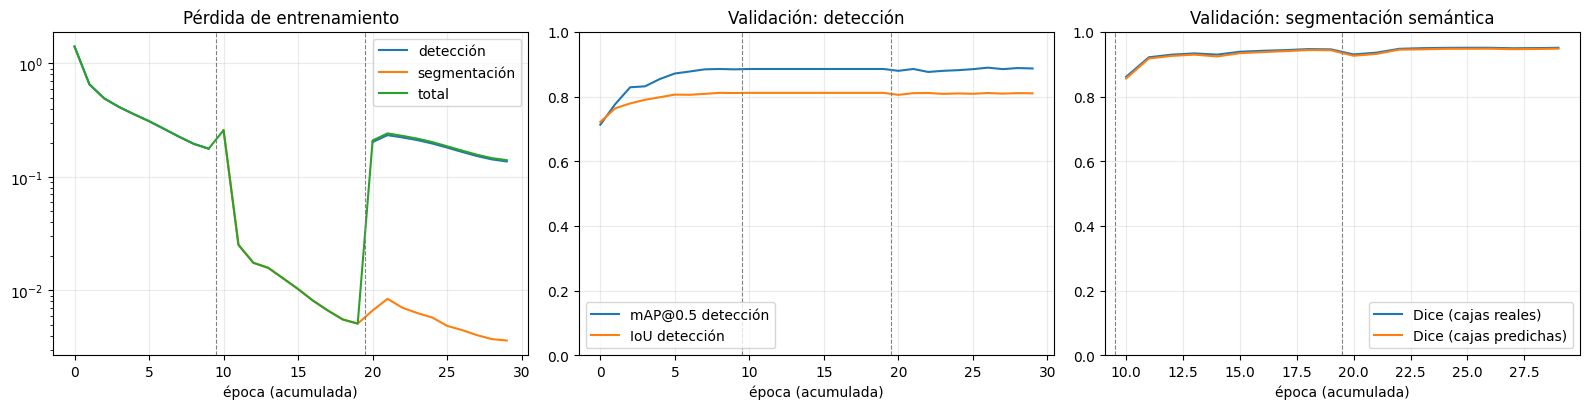

In [26]:
if "history" in globals() and len(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    x = np.arange(len(history))
    for key, label in [("train_det_total", "detección"), ("train_seg_total", "segmentación"), ("train_total", "total")]:
        if key in history:
            axes[0].plot(x, history[key], label=label)
    axes[0].set(title="Pérdida de entrenamiento", xlabel="época (acumulada)"); axes[0].legend(); axes[0].set_yscale("log")
    for key, label in [("val_det_map50", "mAP@0.5 detección"), ("val_det_mean_iou", "IoU detección")]:
        axes[1].plot(x, history[key], label=label)
    axes[1].set(title="Validación: detección", xlabel="época (acumulada)", ylim=(0, 1)); axes[1].legend()
    for key, label in [("val_seg_dice_gt", "Dice (cajas reales)"), ("val_seg_dice_pred", "Dice (cajas predichas)")]:
        if key in history:
            axes[2].plot(x, history[key], label=label)
    axes[2].set(title="Validación: segmentación semántica", xlabel="época (acumulada)", ylim=(0, 1)); axes[2].legend()
    for ax in axes:
        ax.grid(alpha=0.25)
        for b in np.flatnonzero(history["stage"].ne(history["stage"].shift()).to_numpy())[1:]:
            ax.axvline(b - 0.5, color="gray", ls="--", lw=0.8)
    plt.tight_layout(); plt.show()

## Pendientes y advertencias
- **Solo cortes positivos.** El manifiesto no incluye cortes sin hueso. Al inferir sobre todo el volumen (slider, reconstrucción 3D) el modelo producirá falsos positivos en cortes vacíos. Habrá que añadir negativos al manifiesto (Daniela) y muestrearlos.
- **Origen de las piezas.** La cabeza grid, `build_targets`, `grid_detection_loss` y `decode_predictions` se importan de `deteccion_grid.py` (no de `cbam.ipynb`); CBAM y la compuerta residual vienen de `cbam.ipynb`. `deteccion_grid.py` debe estar junto a este cuaderno.
- **NMS y pertenencia (Fabián).** `predicted_boxes_top1` es provisional; la cabeza de pertenencia no se entrena aquí. Si resulta ser una cabeza con pesos, se añade como un módulo y un término más en `compute_losses`.
- **Tamaño de la caché.** ~3.5 GB en RAM para `train` y similar en disco: añadir `evidencias/cache_entrenamiento/` a `.gitignore`.
- **Skip connections.** El decoder usa los mapas intermedios del backbone (`USE_SKIPS = True`). Para la ablación con/sin skips: segunda corrida completa con `USE_SKIPS = False` y otra carpeta de salida; el efecto real todavía no está medido.
- **Selección de checkpoint y pesos de pérdida** (`SEG_WEIGHTS`, `w_det`/`w_seg`, `DET_LAMBDAS`) son puntos de partida: revisar con las curvas y `trunk_grad_*`. `test` no se usa aquí.
- **Reanudar** una corrida: los `last_*.pth` guardan optimizador, scaler y scheduler, pero este cuaderno no implementa la reanudación automática.

In [27]:
# ---------------------------------------------------------------------------
# Exportar el modelo entrenado para inferencia  (pegar en una celda del cuaderno
# de entrenamiento, DESPUES de entrenar). Usa lo que ya existe alli:
# torch, OUT_DIR, DEVICE, MultiTaskNet, CLASS_NAMES, val_loader, load_weights.
#
# Por que no .pkl: pickle guarda el OBJETO completo y lo ata al nombre exacto de
# la clase y del modulo donde se definio (aqui, un cuaderno). Cualquier cambio
# en el codigo lo rompe. Guardando solo los pesos (state_dict) + una descripcion
# de la arquitectura, el archivo se puede reconstruir desde cualquier cuaderno.
# ---------------------------------------------------------------------------

EXPORT_PATH = OUT_DIR / "modelo_multitarea_final.pt"


def export_inference_checkpoint(src_path, dst_path):
    """Convierte un checkpoint de entrenamiento (con optimizador, scaler...) en
    un archivo ligero solo para inferencia."""
    state = torch.load(src_path, map_location="cpu", weights_only=False)
    cfg = state["config"]
    payload = {
        "format_version": 1,
        "model_state_dict": {k: v.cpu() for k, v in state["model_state_dict"].items()},
        "architecture": {
            "class": "MultiTaskNet",
            "backbone_name": cfg["BACKBONE_NAME"],
            "use_cbam": cfg["USE_CBAM"],
            "use_gate": cfg.get("USE_CBAM_GATE", True),
            "use_skips": cfg.get("USE_SKIPS", True),
            "in_channels": 1,
            "image_size": cfg["IMAGE_SIZE"],
            "grid_size": cfg["GRID_SIZE"],
        },
        # Valores por defecto de la inferencia: AJUSTAR con val antes de usarlos como definitivos.
        "inference_defaults": {
            "center_threshold": 0.25,
            "min_center_distance": 7,
            "min_instance_pixels": 1,
            "pred_box_score_min": cfg["PRED_BOX_SCORE_MIN"],
        },
        "class_names": {int(k): str(v) for k, v in CLASS_NAMES.items()},
        "selected_from": {"stage": state["stage"], "epoch": int(state["epoch"]),
                          "val_metrics": state["val_metrics"]},
        "training_config": json.loads(json.dumps(cfg, default=str)),          # solo tipos simples; semilla, etapas, lambdas, versión de datos, git commit...
        "torch_version": str(torch.__version__),
    }
    torch.save(payload, dst_path)
    return payload


def load_trained_model(path, device=DEVICE):
    """Reconstruye el modelo desde el archivo exportado y lo deja en eval()."""
    payload = torch.load(path, map_location=device, weights_only=True)   # solo tensores y tipos simples
    arch = payload["architecture"]
    model = MultiTaskNet(arch["backbone_name"], arch["use_cbam"],
                         arch.get("use_gate", True), arch.get("use_skips", True)).to(device)
    model.load_state_dict(payload["model_state_dict"])
    model.eval()
    return model, payload


# --- 1) exportar el mejor checkpoint de la etapa C (el modelo con las tres salidas) ---
payload = export_inference_checkpoint(OUT_DIR / "best_C_conjunto.pth", EXPORT_PATH)
print(f"Guardado: {EXPORT_PATH}  ({EXPORT_PATH.stat().st_size / 1e6:.1f} MB)")
print("Salio de:", payload["selected_from"]["stage"], "época", payload["selected_from"]["epoch"])

# --- 2) comprobación: el archivo reconstruido da las MISMAS salidas que el checkpoint original ---
reloaded, meta = load_trained_model(EXPORT_PATH)
reference = MultiTaskNet(meta["architecture"]["backbone_name"], meta["architecture"]["use_cbam"],
                         meta["architecture"].get("use_gate", True), meta["architecture"].get("use_skips", True)).to(DEVICE)
load_weights(reference, OUT_DIR / "best_C_conjunto.pth")
reference.eval()

x = next(iter(val_loader))["image"][:4].to(DEVICE)
with torch.no_grad():
    f_ref, f_new = reference.trunk(x), reloaded.trunk(x)
    d_ref, d_new = reference.det_head(f_ref[-1]), reloaded.det_head(f_new[-1])
assert all(torch.allclose(a, b, atol=1e-6) for a, b in zip(f_ref, f_new)) and torch.allclose(d_ref, d_new, atol=1e-6)
print("Comprobación OK: el modelo reconstruido coincide con el original.")

Guardado: d:\proyecto_analitica_corte2\evidencias\entrenamiento_multitarea\modelo_multitarea_final.pt  (10.1 MB)
Salio de: C_conjunto época 7
Comprobación OK: el modelo reconstruido coincide con el original.


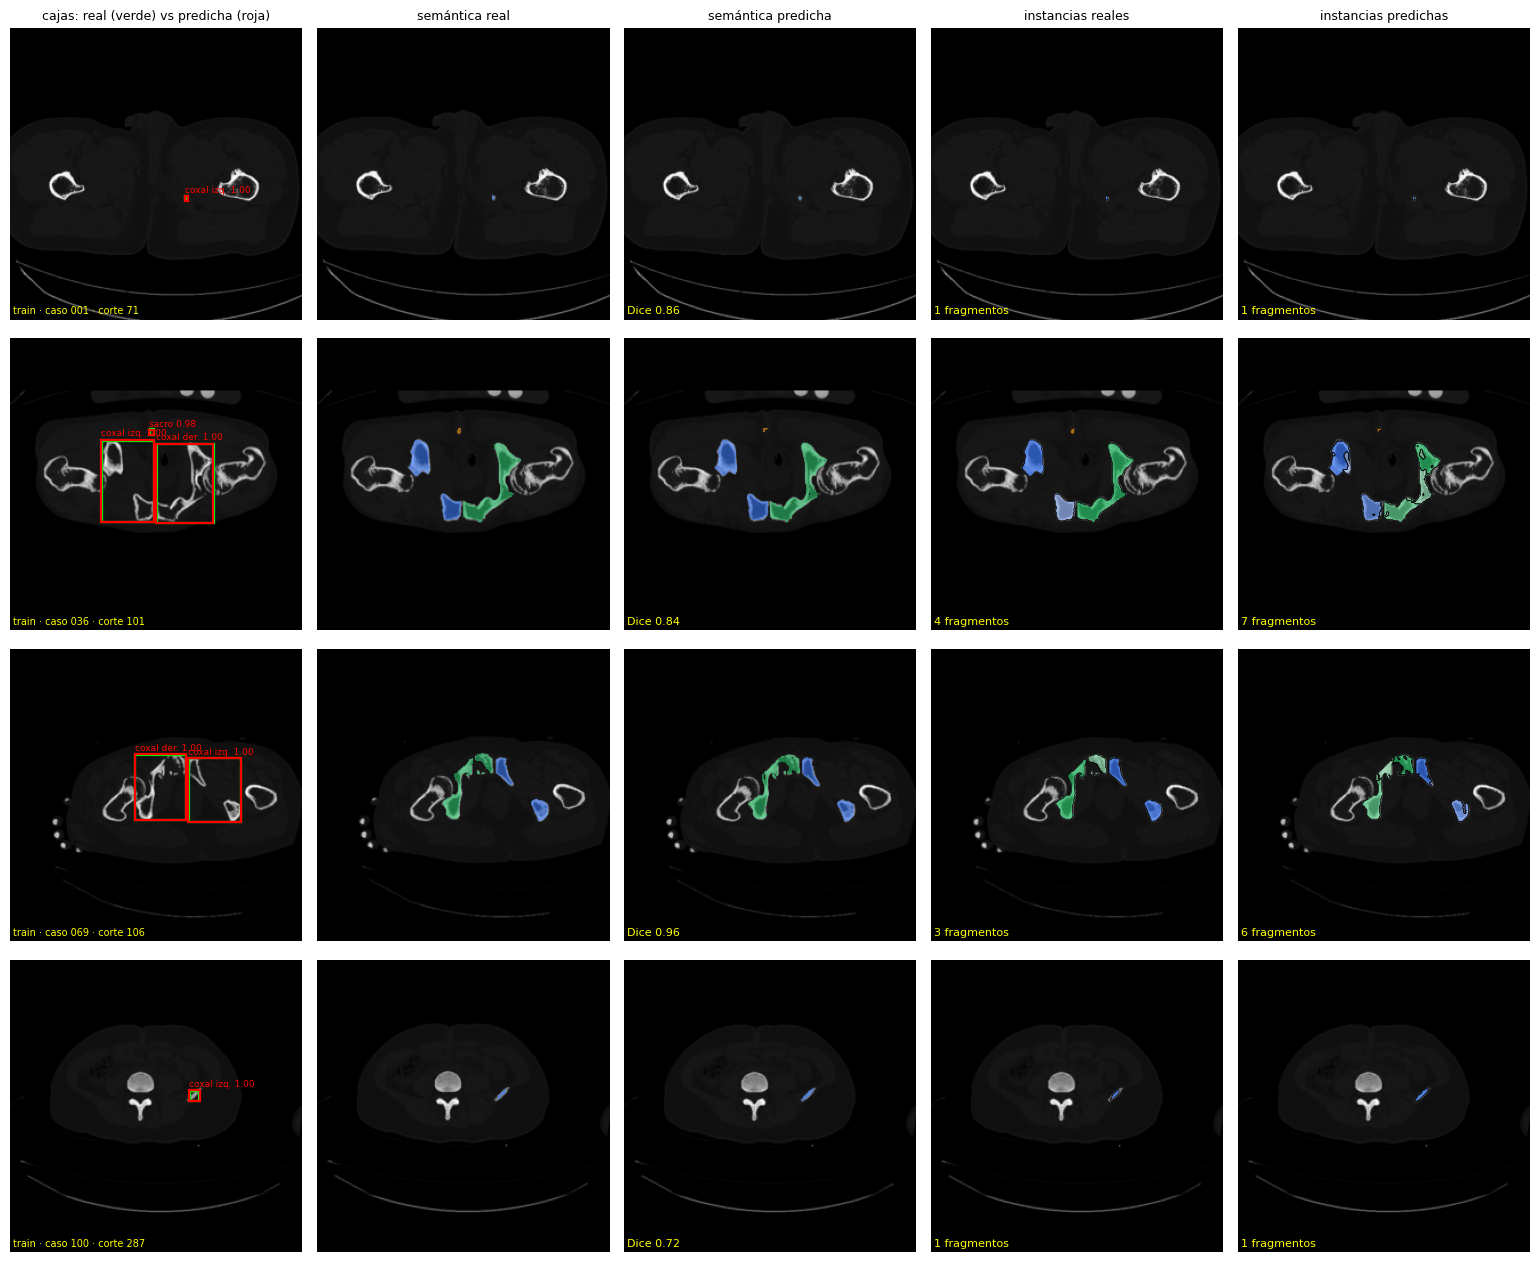

Guardada: d:\proyecto_analitica_corte2\evidencias\entrenamiento_multitarea\vis_train_spread.png


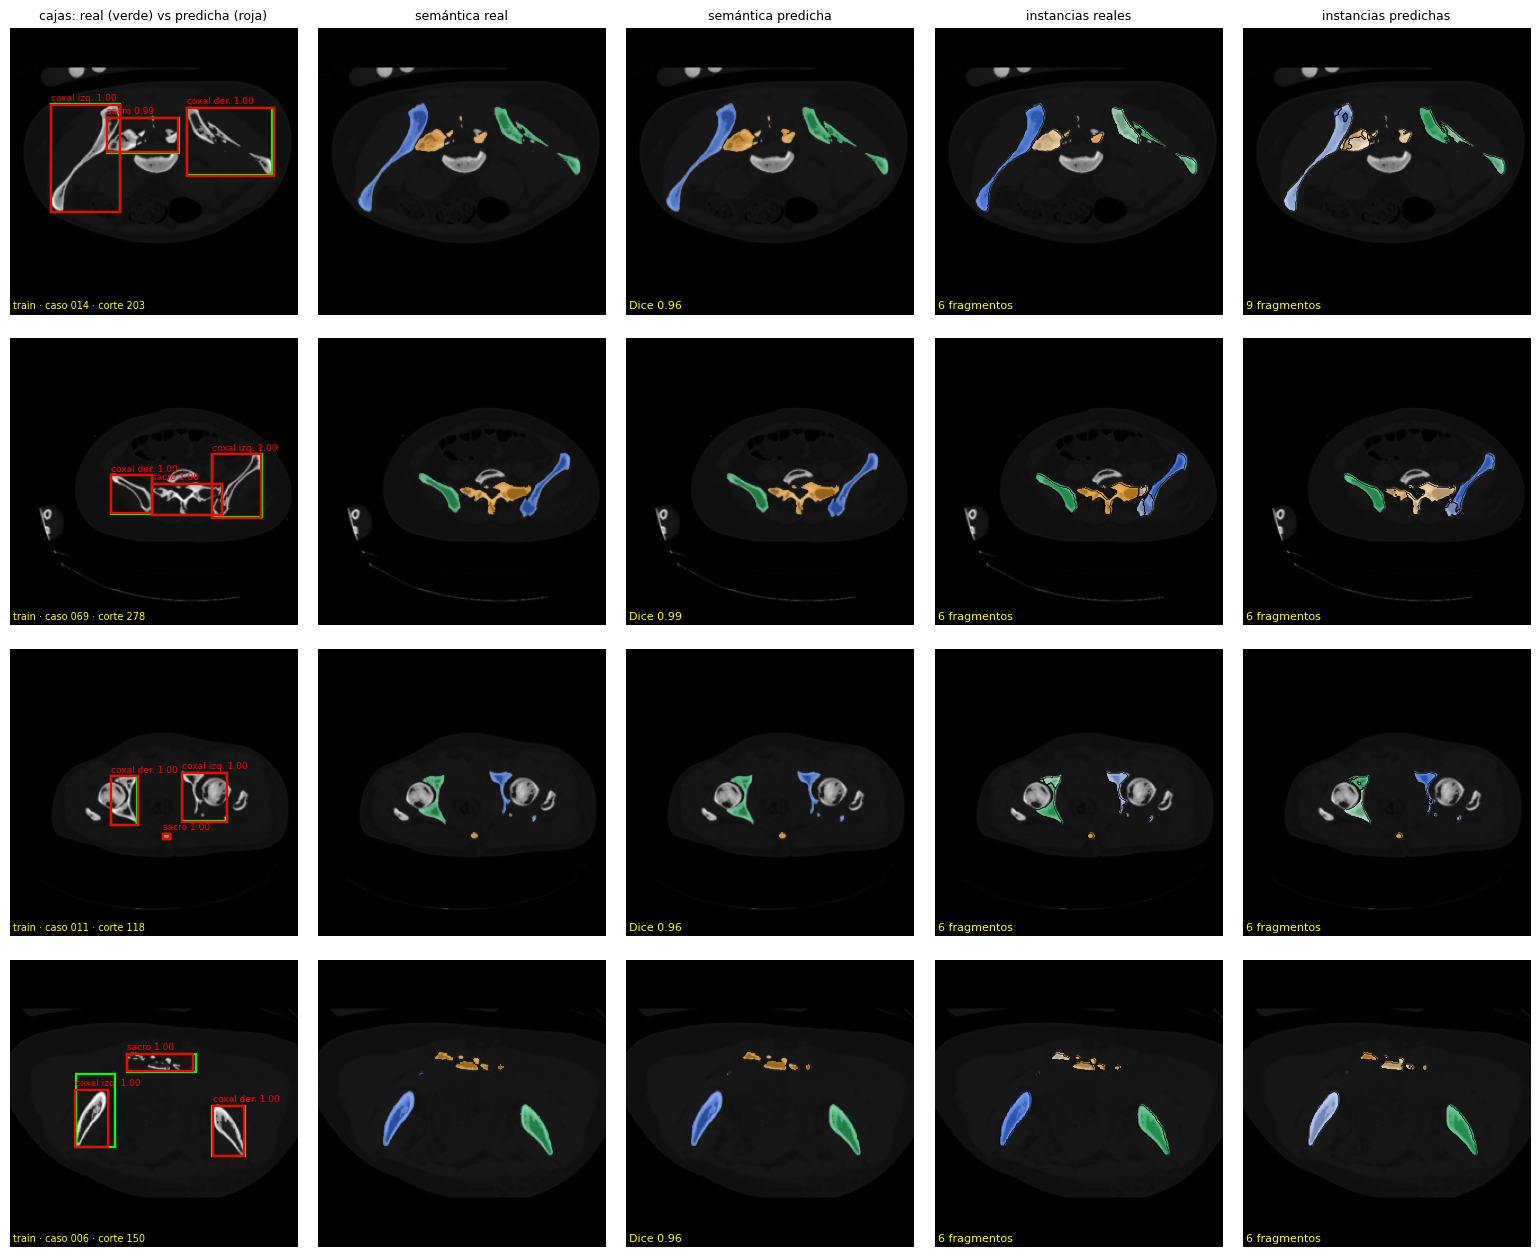

Guardada: d:\proyecto_analitica_corte2\evidencias\entrenamiento_multitarea\vis_train_fragments.png


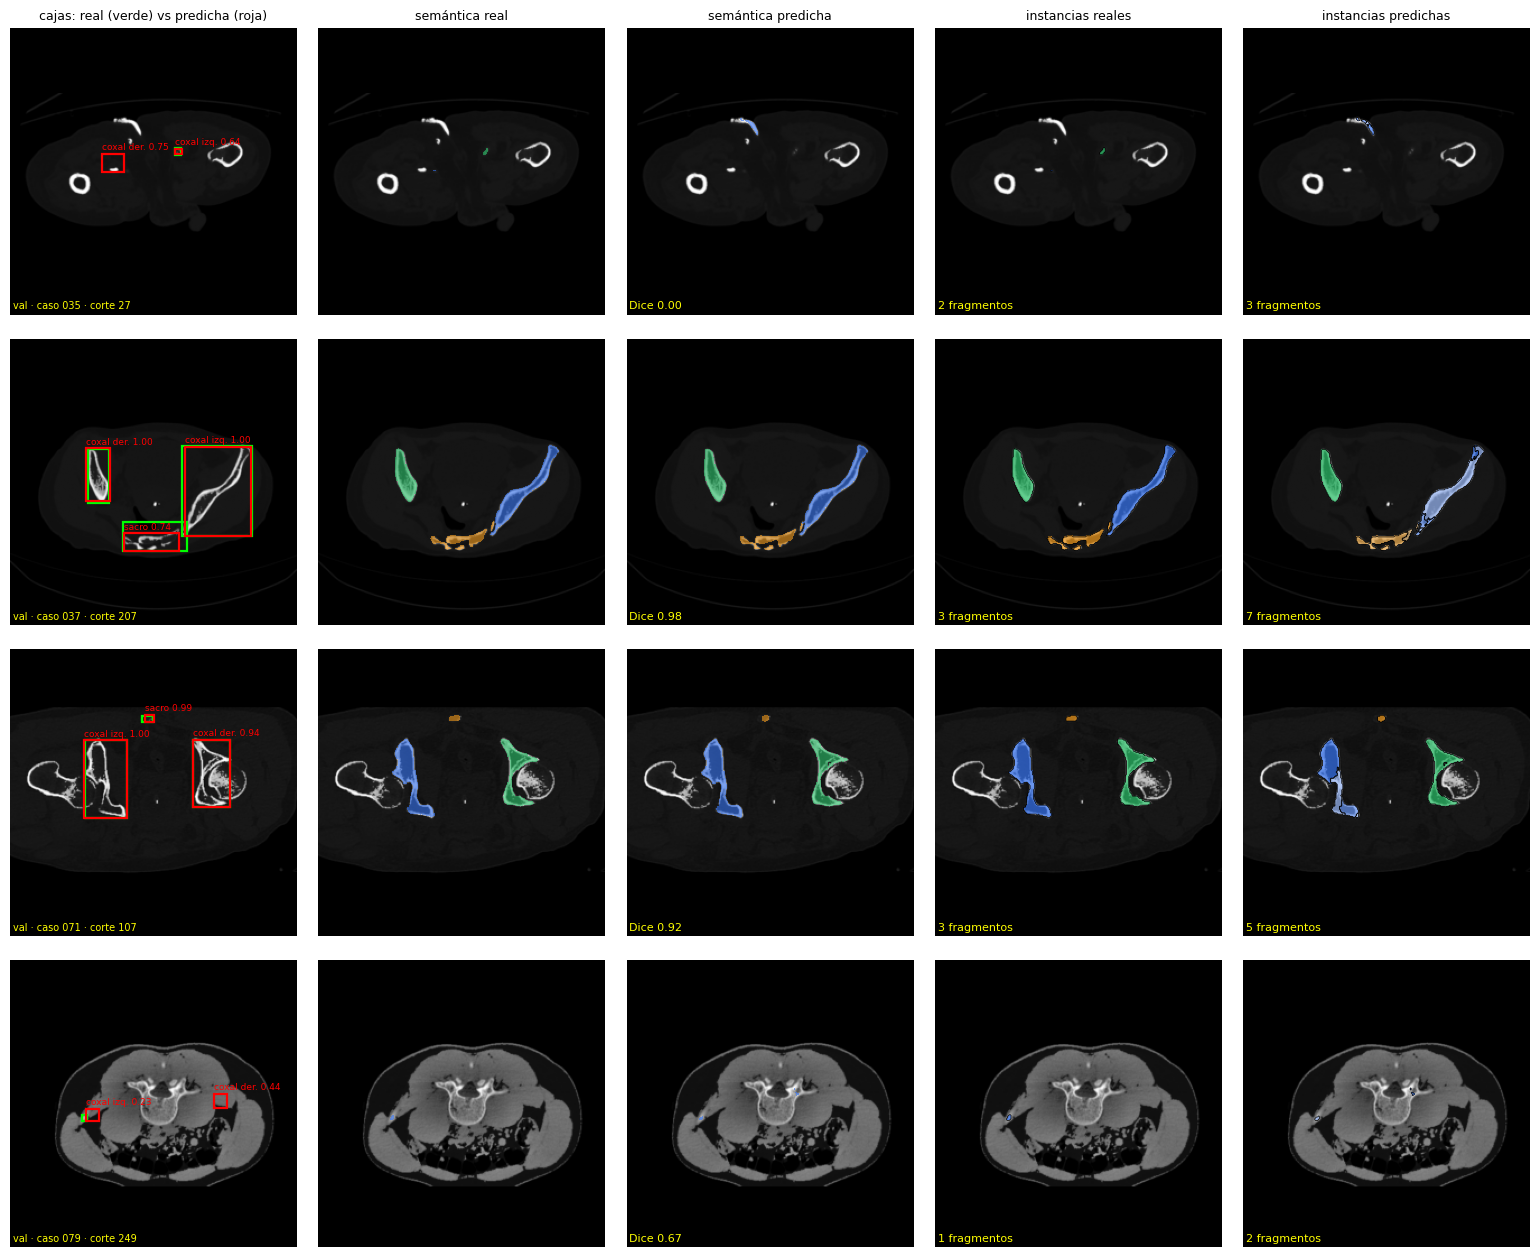

Guardada: d:\proyecto_analitica_corte2\evidencias\entrenamiento_multitarea\vis_val_spread.png


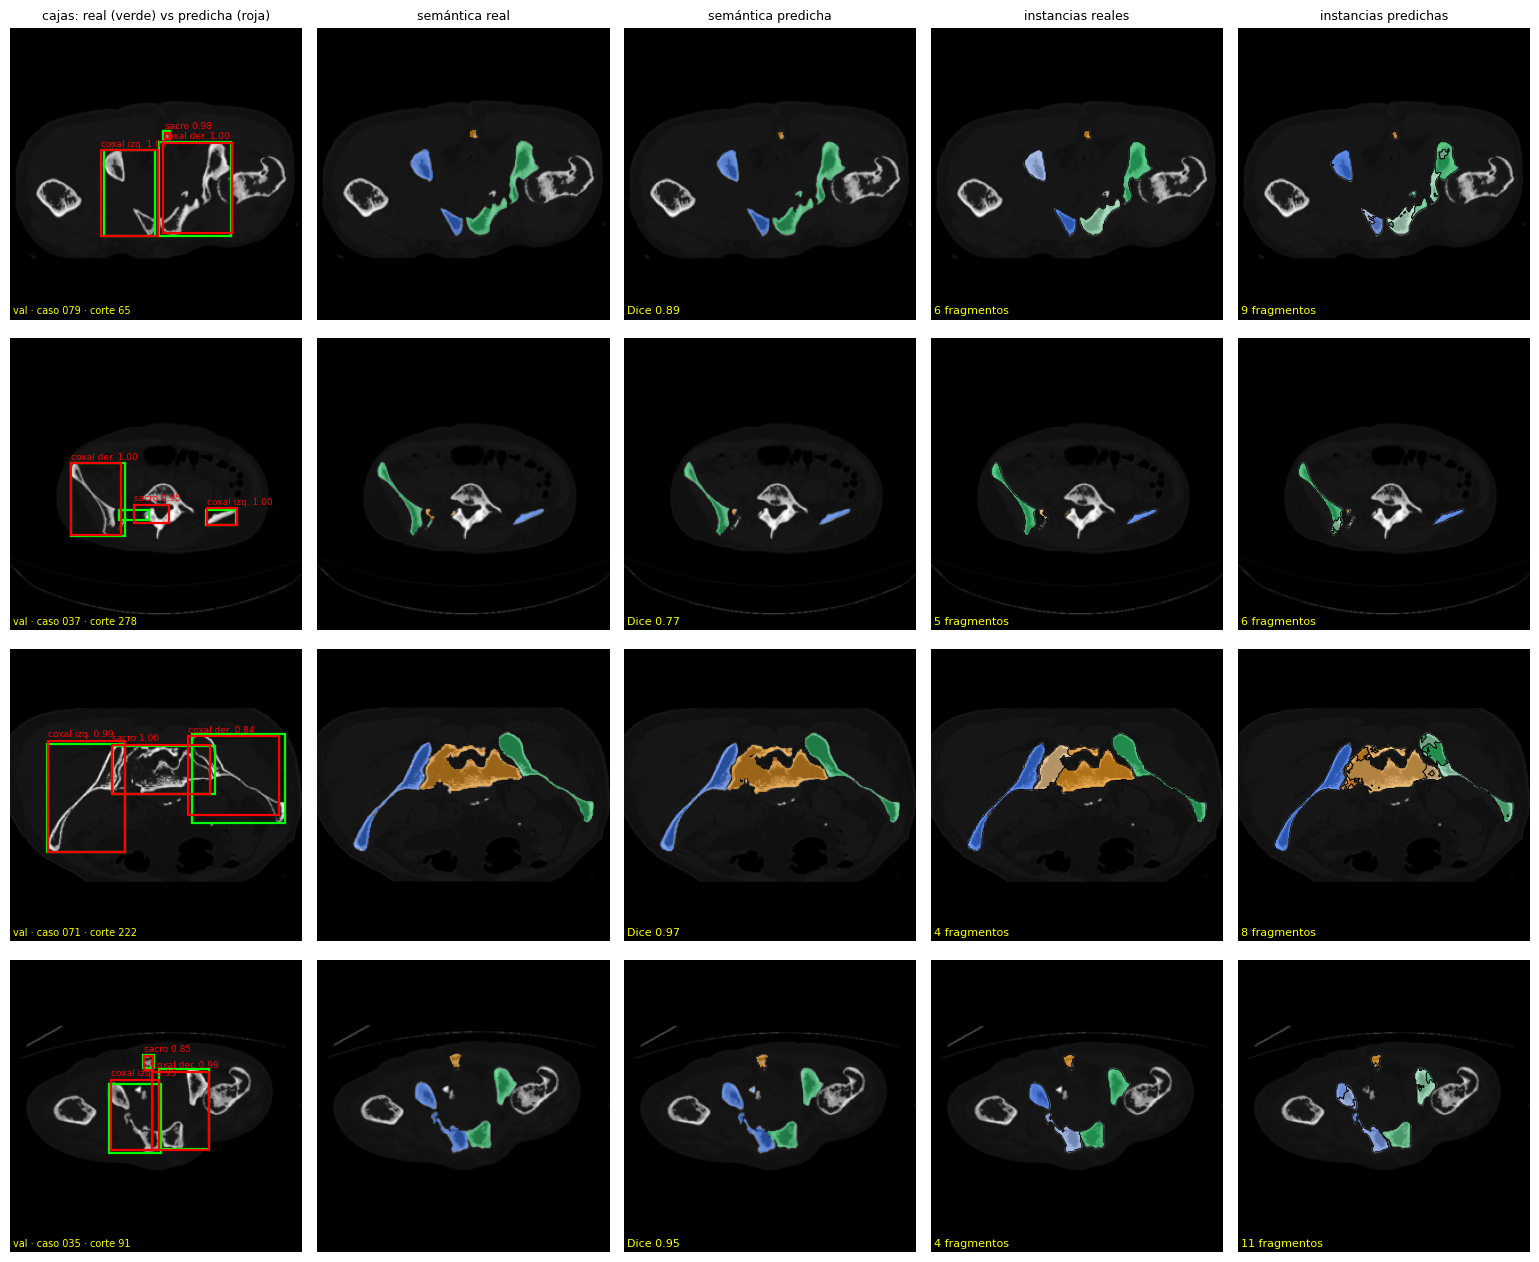

Guardada: d:\proyecto_analitica_corte2\evidencias\entrenamiento_multitarea\vis_val_fragments.png


In [28]:
# ---------------------------------------------------------------------------
# Visualizar detección + segmentación (semántica e instancias) en train y val.
# Pegar en una celda del cuaderno de entrenamiento, DESPUES de entrenar.
# Usa lo que ya existe alli: torch, np, plt, OUT_DIR, DEVICE, IMAGE_SIZE, autocast,
# collate_slices, decode_predictions, build_detection_region_priors,
# decode_center_offset_instances, train_loader, val_loader y el modelo `model`
# (tras entrenar queda con los mejores pesos de la etapa C).
#
# Columnas:  1) cajas reales (verde) vs predichas (roja) | 2) semántica real
#            3) semántica predicha | 4) instancias reales | 5) instancias predichas
# Color = región anatómica; el tono distinto separa fragmentos de la misma región.
# ---------------------------------------------------------------------------
from matplotlib.patches import Rectangle

REGION_NAMES = {1: "sacro", 2: "coxal izq.", 3: "coxal der."}
REGION_RGB = {1: (0.95, 0.60, 0.10), 2: (0.20, 0.45, 0.95), 3: (0.15, 0.75, 0.40)}
SHADES = [0.0, 0.5, 0.25, 0.7, 0.35, 0.8]


def _id_to_class(i):                         # mismo convenio de IDs que la sección 23
    return 1 if i <= 10 else 2 if i <= 20 else 3


def _semantic_rgba(sem, alpha=0.6):
    rgba = np.zeros((*sem.shape, 4), dtype=np.float32)
    for c, rgb in REGION_RGB.items():
        m = sem == c
        rgba[m, :3] = rgb
        rgba[m, 3] = alpha
    return rgba


def _instance_rgba(inst, id_to_class, alpha=0.7):
    rgba = np.zeros((*inst.shape, 4), dtype=np.float32)
    per_class = defaultdict(list)
    for i in np.unique(inst):
        if i != 0:
            per_class[id_to_class[int(i)]].append(int(i))
    for c, ids in per_class.items():
        for j, i in enumerate(sorted(ids)):
            s = SHADES[j % len(SHADES)]
            m = inst == i
            rgba[m, :3] = np.array(REGION_RGB[c]) * (1 - s) + s
            rgba[m, 3] = alpha
    return rgba


def _draw_contours(ax, inst):
    for i in np.unique(inst):
        if i != 0:
            ax.contour(inst == i, levels=[0.5], colors="k", linewidths=0.5)


def _draw_boxes(ax, boxes, labels, color, scores=None, label=True):
    for k, (b, c) in enumerate(zip(boxes, labels)):
        ax.add_patch(Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec=color, lw=1.6))
        if label:
            txt = REGION_NAMES.get(int(c), str(c)) + (f" {scores[k]:.2f}" if scores is not None else "")
            ax.text(b[0], max(b[1] - 2, 7), txt, color=color, fontsize=6.5, va="bottom")


def _top1_with_scores(decoded_i, score_min=PRED_BOX_SCORE_MIN):
    # Misma regla que predicted_boxes_top1 (marcador de posición del NMS), pero devolviendo el score.
    boxes, labels, scores = [], [], []
    for c in (1, 2, 3):
        idx = (decoded_i["labels"] == c).nonzero(as_tuple=True)[0]
        if len(idx) == 0:
            continue
        j = idx[decoded_i["scores"][idx].argmax()]
        if float(decoded_i["scores"][j]) >= score_min:
            boxes.append(decoded_i["boxes"][j].detach().cpu().numpy())
            labels.append(c)
            scores.append(float(decoded_i["scores"][j]))
    return np.asarray(boxes, np.float32).reshape(-1, 4), np.asarray(labels, np.int64), np.asarray(scores, np.float32)


def _slice_dice(pred, gt):
    ds = []
    for c in (1, 2, 3):
        g, p = gt == c, pred == c
        if g.any():
            ds.append(2 * (g & p).sum() / (g.sum() + p.sum()))
    return float(np.mean(ds)) if ds else float("nan")


def _pick_indices(ds, n, mode, rng):
    if mode == "spread":                      # repartidos por todo el split (varios pacientes)
        return np.linspace(0, len(ds) - 1, n).astype(int)
    # "fragments": cortes con más fragmentos, de casos distintos, dentro de un grupo aleatorio
    pool = rng.choice(len(ds), size=min(1500, len(ds)), replace=False)
    counts = np.array([len(np.unique(ds.inst[i])) - 1 for i in pool])
    order = np.argsort(-counts)
    chosen, seen = [], set()
    for k in order:
        if ds.case_ids[pool[k]] not in seen:
            chosen.append(int(pool[k])); seen.add(ds.case_ids[pool[k]])
        if len(chosen) == n:
            break
    for k in order:                           # si hay menos casos que n, completar
        if len(chosen) == n:
            break
        if int(pool[k]) not in chosen:
            chosen.append(int(pool[k]))
    return np.array(chosen)


@torch.no_grad()
def visualize_predictions(model, dataset, split_name, n=4, mode="spread", seed=0,
                          center_threshold=0.25, min_center_distance=7, min_instance_pixels=1):
    rng = np.random.default_rng(seed)
    idxs = _pick_indices(dataset, n, mode, rng)
    batch = collate_slices([dataset[int(i)] for i in idxs])
    model.eval()
    with autocast():
        x = batch["image"].to(DEVICE)
        feats = model.trunk(x)
        det_logits = model.det_head(feats[-1])
    decoded = decode_predictions(det_logits.float(), score_thresh=0.0, img_size=IMAGE_SIZE)
    tops = [_top1_with_scores(d) for d in decoded]
    priors = build_detection_region_priors([{"boxes": b, "labels": l} for b, l, _ in tops],
                                           output_size=(IMAGE_SIZE, IMAGE_SIZE), device=DEVICE)
    with autocast():
        seg_out = model.seg_decoder(x, feats, priors)          # el decoder usa las cajas PREDICHAS

    titles = ["cajas: real (verde) vs predicha (roja)", "semántica real", "semántica predicha",
              "instancias reales", "instancias predichas"]
    fig, axes = plt.subplots(n, 5, figsize=(15.5, 3.2 * n))
    axes = np.atleast_2d(axes)
    for r in range(n):
        img = batch["image"][r, 0].numpy()
        gt_sem, gt_inst = batch["semantic"][r].numpy(), batch["instance_mask"][r].numpy()
        one = {k: v[r:r + 1].float() for k, v in seg_out.items()}
        pred_inst, pred_sem, pred_cls = decode_center_offset_instances(
            one, center_threshold, min_center_distance, min_instance_pixels)
        pb, pl, ps = tops[r]
        n_gt = int((np.unique(gt_inst) != 0).sum())
        gt_cls = {int(i): _id_to_class(int(i)) for i in np.unique(gt_inst) if i != 0}

        panels = [None, _semantic_rgba(gt_sem), _semantic_rgba(pred_sem),
                  _instance_rgba(gt_inst, gt_cls), _instance_rgba(pred_inst, pred_cls)]
        for j, ax in enumerate(axes[r]):
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
            if panels[j] is not None:
                ax.imshow(panels[j], interpolation="nearest")
            ax.axis("off")
            if r == 0:
                ax.set_title(titles[j], fontsize=9)
        _draw_boxes(axes[r, 0], batch["boxes"][r], batch["labels"][r], "lime", label=False)
        _draw_boxes(axes[r, 0], pb, pl, "red", ps)
        _draw_contours(axes[r, 3], gt_inst)
        _draw_contours(axes[r, 4], pred_inst)
        axes[r, 0].text(2, 252, f"{split_name} · caso {batch['case_id'][r]} · corte {batch['slice_index'][r]}",
                        color="yellow", fontsize=7, va="bottom")
        axes[r, 2].text(2, 252, f"Dice {_slice_dice(pred_sem, gt_sem):.2f}", color="yellow", fontsize=8, va="bottom")
        axes[r, 3].text(2, 252, f"{n_gt} fragmentos", color="yellow", fontsize=8, va="bottom")
        axes[r, 4].text(2, 252, f"{len(pred_cls)} fragmentos", color="yellow", fontsize=8, va="bottom")
    plt.tight_layout()
    out = OUT_DIR / f"vis_{split_name}_{mode}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print("Guardada:", out)


# --- uso: el modelo en memoria tiene los mejores pesos de la etapa C ---
trained = model            # o:  trained, _ = load_trained_model(EXPORT_PATH)
for split_name, loader in (("train", train_loader), ("val", val_loader)):
    visualize_predictions(trained, loader.dataset, split_name, n=4, mode="spread")      # repartidos
    visualize_predictions(trained, loader.dataset, split_name, n=4, mode="fragments")   # con más fragmentos